# The Ray Tracing Sampler

The Ray Tracing sampler (Behroozi 2025) is a physics-inspired MCMC method
that propagates "light rays" through a medium where the refractive index
is set by the posterior density: $n(\mathbf{x}) = \mathcal{L}(\mathbf{x})^{1/(D-1)}$.
Snell's law bends rays toward high-likelihood regions, producing fair
posterior samples.

**Key advantages over HMC/NUTS:**
- Orders of magnitude more resilient to stochastic/noisy gradients
- No energy conservation requirement (constant speed propagation)
- Can cross arbitrary likelihood barriers
- Simple Metropolis correction

This notebook demonstrates RT on both low-D (parametric, D=7) and high-D
(stochastic, D~137) models, with diagnostic guidance.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    Observation,
    ParamSpec,
    Photometry,
    Uniform,
    load_ssp_data,
)

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

from _plot_style import (
    COLORS,
    convergence_table,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

FIGDIR = os.path.join(_nb_dir, "..", "figures", "reference")
os.makedirs(FIGDIR, exist_ok=True)

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
)

## 1. Snell's Law Physics Analogy

In classical optics, Snell's law bends light at interfaces between media
with different refractive indices. The RT sampler generalizes this to a
continuous medium where:

$$n(\mathbf{x}) = \mathcal{L}(\mathbf{x})^{1/(D-1)}$$

The ray equation becomes:

$$\frac{d\mathbf{v}}{ds} = \frac{1}{D-1} \nabla \log \mathcal{L}$$

This naturally produces Metropolis-corrected samples that concentrate
in high-posterior regions.

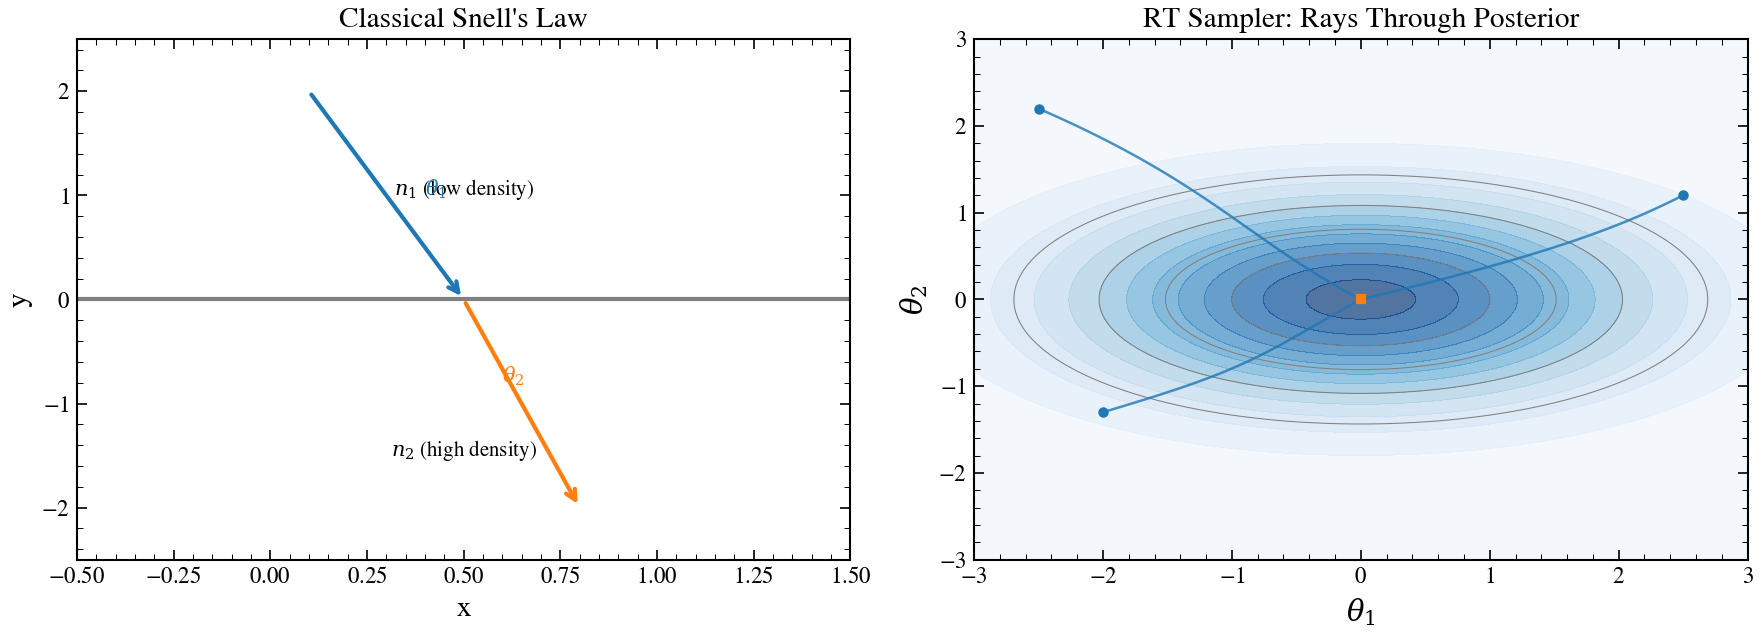

In [3]:
# --- FIGURE 1: Snell's law analogy ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: Classical Snell's law
ax = axes[0]
ax.axhline(0, color="grey", lw=2)
ax.annotate(
    r"$n_1$ (low density)", xy=(0.5, 0.7), xycoords="axes fraction", fontsize=10, ha="center"
)
ax.annotate(
    r"$n_2$ (high density)", xy=(0.5, 0.2), xycoords="axes fraction", fontsize=10, ha="center"
)
# Incoming ray
ax.annotate(
    "",
    xy=(0.5, 0.0),
    xytext=(0.1, 2.0),
    arrowprops=dict(arrowstyle="->", color=COLORS["rt"], lw=2),
)
# Refracted ray
ax.annotate(
    "",
    xy=(0.8, -2.0),
    xytext=(0.5, 0.0),
    arrowprops=dict(arrowstyle="->", color=COLORS["geovi"], lw=2),
)
ax.annotate(r"$\theta_1$", xy=(0.4, 1.0), fontsize=10, color=COLORS["rt"])
ax.annotate(r"$\theta_2$", xy=(0.6, -0.8), fontsize=10, color=COLORS["geovi"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-2.5, 2.5)
ax.set_title("Classical Snell's Law")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Right: RT sampler concept — rays through posterior landscape
ax = axes[1]
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
# 2D Gaussian posterior
Z = np.exp(-0.5 * (X**2 / 1.5**2 + Y**2 / 0.8**2))
ax.contourf(X, Y, Z, levels=15, cmap="Blues", alpha=0.7)
ax.contour(X, Y, Z, levels=5, colors="grey", linewidths=0.5)
# Example ray trajectories (schematic)
for _i, (x0, y0) in enumerate([(-2.5, 2.0), (-2.0, -1.5), (2.5, 1.0)]):
    # Simple curved path toward center
    t = np.linspace(0, 1, 50)
    ray_x = x0 * (1 - t) + 0.3 * np.sin(3 * t) * (1 - t)
    ray_y = y0 * (1 - t) + 0.2 * np.cos(2 * t) * (1 - t)
    ax.plot(ray_x, ray_y, color=COLORS["rt"], lw=1.2, alpha=0.8)
    ax.plot(ray_x[0], ray_y[0], "o", color=COLORS["rt"], ms=4)
    ax.plot(ray_x[-1], ray_y[-1], "s", color=COLORS["geovi"], ms=4)
ax.set_title("RT Sampler: Rays Through Posterior")
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "08_snell_law.png"), bbox_inches="tight")
plt.show()

## 2. RT on a Parametric Model (D = 7)

First we demonstrate RT on a simple parametric model where NUTS also
works, allowing direct comparison.

In [4]:
spec_param = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
)

model_param = Model(spec_param, ssp_data, observation=obs)
truth_param = {
    "sfh_tsnorm_log_peak_sfr": 0.8,
    "sfh_tsnorm_peak_lbt_gyr": 4.0,
    "sfh_tsnorm_width_gyr": 2.0,
    "sfh_tsnorm_skew": 0.3,
    "sfh_tsnorm_trunc": 5.0,
    "met_logzsol": -0.2,
    "dust_tau_bc": 0.3,
    "dust_tau_diff": 0.5,
    "dust_slope": -0.7,
    "redshift": 0.1,
}
mock_param = model_param.mock(truth_param, snr=20.0, key=jax.random.PRNGKey(42))

# MAP initialization
fitter_param = Fitter(model_param, mock_param.flux_obs, mock_param.noise)
result_map = fitter_param.run("map", n_steps=500, learning_rate=0.02)

# Ray Tracing
t0 = time.time()
result_rt = fitter_param.run(
    "raytrace",
    init_from=result_map,
    n_steps=500,
    n_burnin=100,
    step_size=0.1,
    n_leapfrog_steps=20,
)
rt_time = time.time() - t0
print(f"RT (D=7): {rt_time:.1f}s")

W0325 11:54:47.948396 20176386 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_28600/2460179626.py:14: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_param = Model(spec_param, ssp_data, observation=obs)


  Step     0/500: loss = 269.6190
  Step   200/500: loss = 3.4047
  Step   400/500: loss = 2.6970
  Step   499/500: loss = 2.3320
  MAP (ADAM) complete in 0.4s, 500 steps


Ray Tracing: 8 params, 100 burn-in + 500 samples, 20 leapfrog/step, step_size=0.1000


  Ray Tracing complete in 0.8s. Acceptance: 0.0% (overall), 0.0% (post burn-in). Samples: 500
RT (D=7): 1.8s


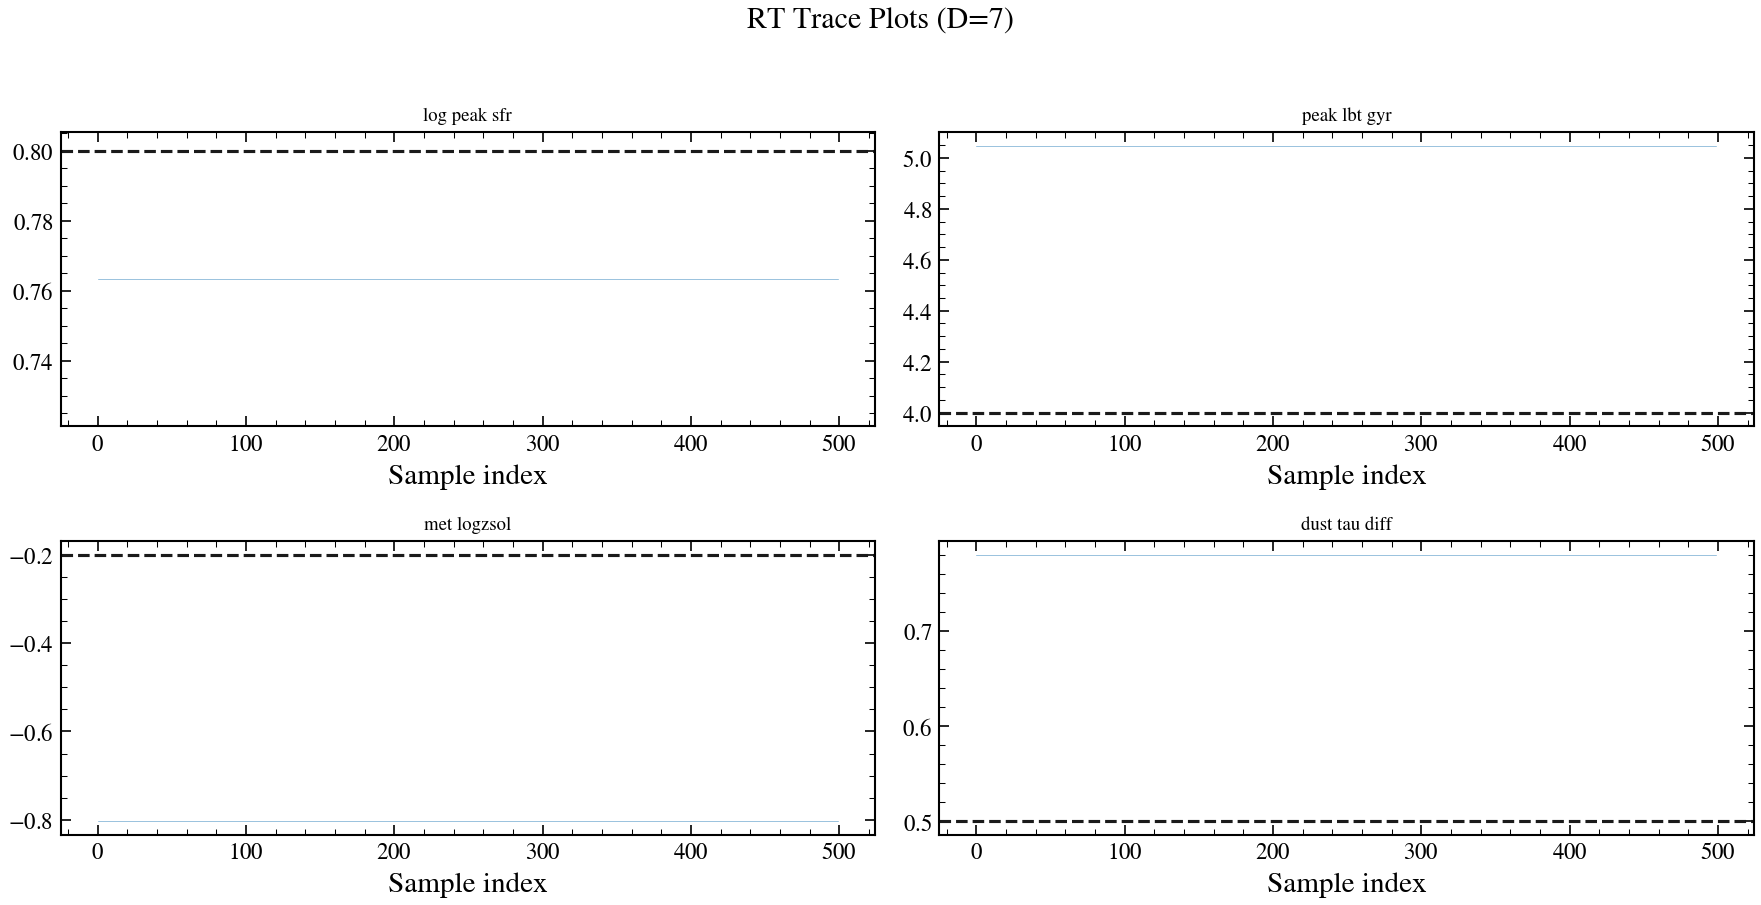

In [5]:
# --- FIGURE 2: RT trace plots and diagnostics ---
if result_rt.samples is not None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    params_show = [
        "sfh_tsnorm_log_peak_sfr",
        "sfh_tsnorm_peak_lbt_gyr",
        "met_logzsol",
        "dust_tau_diff",
    ]
    for ax, param in zip(axes.flat, params_show):
        if param in result_rt.samples:
            samples = np.array(result_rt.samples[param])
            ax.plot(samples, color=COLORS["rt"], lw=0.3, alpha=0.7)
            ax.axhline(truth_param[param], color=COLORS["truth"], ls="--", lw=1.5)
            display = param.replace("sfh_tsnorm_", "").replace("_", " ")
            ax.set_title(display, fontsize=9)
            ax.set_xlabel("Sample index")
    fig.suptitle("RT Trace Plots (D=7)", y=1.02)
    fig.tight_layout()
    plt.savefig(os.path.join(FIGDIR, "08_rt_traces_d7.png"), bbox_inches="tight")
    plt.show()

In [6]:
# Convergence diagnostics
convergence_table({"RT (D=7)": result_rt})

Method           ESS min  ESS med   Accept   Diverg     Status
--------------------------------------------------------------
RT (D=7)             500      500       0%        —       WARN

Warnings:
  [RT (D=7)] RT acceptance 0% too low — reduce step_size


{'RT (D=7)': {'ess_min': np.float64(500.0),
  'ess_median': 500.0,
  'n_params_low_ess': 0,
  'acceptance_rate': 1.3011754206251006e-196,
  'converged': False,
  'warnings': ['RT acceptance 0% too low — reduce step_size']}}

## 3. RT on a Stochastic Model (D ~ 137)

The stochastic model has ~130 extra latent dimensions from the GP. RT
handles this dimensionality well, while NUTS struggles.

In [7]:
spec_stoch = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    sfh_field_psd_sigma=Uniform(0.01, 3.0),
    sfh_field_psd_tau_myr=Uniform(5, 500),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type=["tsnorm", "field"],
    n_grid=128,
)

model_stoch = Model(spec_stoch, ssp_data, observation=obs)
truth_stoch = {
    "sfh_tsnorm_log_peak_sfr": 0.8,
    "sfh_tsnorm_peak_lbt_gyr": 4.0,
    "sfh_tsnorm_width_gyr": 2.0,
    "sfh_tsnorm_skew": 0.0,
    "sfh_tsnorm_trunc": 5.0,
    "sfh_field_psd_sigma": 1.0,
    "sfh_field_psd_tau_myr": 50.0,
    "met_logzsol": -0.3,
    "dust_tau_bc": 0.3,
    "dust_tau_diff": 0.5,
    "dust_slope": -0.7,
    "redshift": 0.1,
}
mock_stoch = model_stoch.mock(truth_stoch, snr=20.0, key=jax.random.PRNGKey(0))

fitter_stoch = Fitter(model_stoch, mock_stoch.flux_obs, mock_stoch.noise)
result_map_stoch = fitter_stoch.run("map", n_steps=800, learning_rate=0.01)

t0 = time.time()
result_rt_stoch = fitter_stoch.run(
    "raytrace",
    init_from=result_map_stoch,
    n_steps=300,
    n_burnin=100,
    step_size=0.05,
    n_leapfrog_steps=50,
)
rt_stoch_time = time.time() - t0
print(f"RT (D~137): {rt_stoch_time:.1f}s")

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_28600/2823258231.py:18: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_stoch = Model(spec_stoch, ssp_data, observation=obs)


  Step     0/800: loss = 511.3689
  Step   200/800: loss = 2.3432
  Step   400/800: loss = 1.9826
  Step   600/800: loss = 1.7471
  Step   799/800: loss = 1.6077
  MAP (ADAM) complete in 0.4s, 800 steps
Ray Tracing: 138 params, 100 burn-in + 300 samples, 50 leapfrog/step, step_size=0.0500


  Ray Tracing complete in 0.7s. Acceptance: 0.0% (overall), 0.0% (post burn-in). Samples: 300
RT (D~137): 1.7s


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_28600/69786297.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


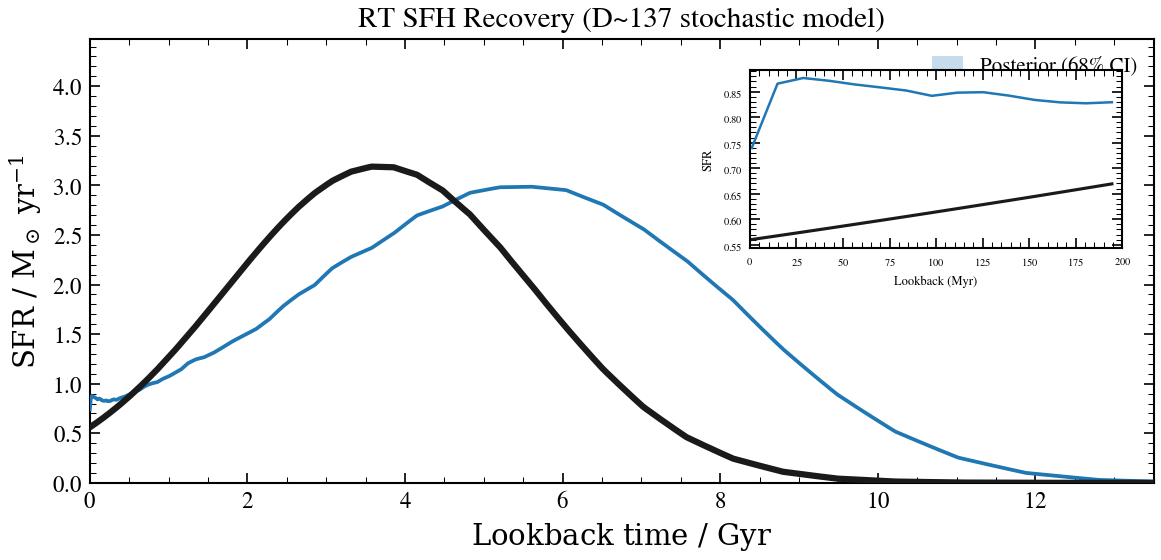

In [8]:
# --- FIGURE 3: SFH recovery from stochastic model ---
fig, ax = plt.subplots(figsize=(8, 4))
plot_sfh(
    model_stoch,
    result_rt_stoch,
    true_params=truth_stoch,
    ax=ax,
    n_draws=30,
    color=COLORS["rt"],
)
ax.set_title("RT SFH Recovery (D~137 stochastic model)")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "08_rt_sfh_d137.png"), bbox_inches="tight")
plt.show()

In [9]:
# Convergence diagnostics for D~137
convergence_table({"RT (D=137)": result_rt_stoch})

Method           ESS min  ESS med   Accept   Diverg     Status
--------------------------------------------------------------
RT (D=137)           300      300       0%        —       WARN

Warnings:
  [RT (D=137)] Median ESS = 300 < 400 target — consider more samples
  [RT (D=137)] RT acceptance 0% too low — reduce step_size


{'RT (D=137)': {'ess_min': np.float64(300.0),
  'ess_median': 300.0,
  'n_params_low_ess': 0,
  'acceptance_rate': 0.0,
  'converged': False,
  'warnings': ['Median ESS = 300 < 400 target — consider more samples',
   'RT acceptance 0% too low — reduce step_size']}}

## 4. Step Size Guide

The step size is the critical tuning parameter for RT. Too large and
acceptance drops to zero; too small and the chain mixes slowly.

| Dimensionality | Recommended step_size | n_leapfrog | Acceptance target |
|---------------|----------------------|------------|-------------------|
| D ~ 7 | 0.05 - 0.15 | 10-30 | 40-70% |
| D ~ 20 | 0.03 - 0.10 | 20-40 | 30-60% |
| D ~ 137 | 0.03 - 0.06 | 30-50 | 30-60% |

**Warning**: For D~137 there is a sharp viability cliff at step_size ~ 0.06
where acceptance drops from ~98% to 0%. Use step_size = 0.05 as a safe
default and compensate with more leapfrog steps.

Ray Tracing: 8 params, 20 burn-in + 100 samples, 15 leapfrog/step, step_size=0.0200


  Ray Tracing complete in 0.6s. Acceptance: 40.6% (overall), 36.3% (post burn-in). Samples: 100
Ray Tracing: 8 params, 20 burn-in + 100 samples, 15 leapfrog/step, step_size=0.0500


  Ray Tracing complete in 0.5s. Acceptance: 0.0% (overall), 0.0% (post burn-in). Samples: 100
Ray Tracing: 8 params, 20 burn-in + 100 samples, 15 leapfrog/step, step_size=0.0800


  Ray Tracing complete in 0.5s. Acceptance: 0.0% (overall), 0.0% (post burn-in). Samples: 100
Ray Tracing: 8 params, 20 burn-in + 100 samples, 15 leapfrog/step, step_size=0.1000


  Ray Tracing complete in 0.5s. Acceptance: 0.0% (overall), 0.0% (post burn-in). Samples: 100
Ray Tracing: 8 params, 20 burn-in + 100 samples, 15 leapfrog/step, step_size=0.1500


  Ray Tracing complete in 0.5s. Acceptance: 0.0% (overall), 0.0% (post burn-in). Samples: 100
Ray Tracing: 8 params, 20 burn-in + 100 samples, 15 leapfrog/step, step_size=0.2000


  Ray Tracing complete in 0.6s. Acceptance: 0.0% (overall), 0.0% (post burn-in). Samples: 100
Ray Tracing: 8 params, 20 burn-in + 100 samples, 15 leapfrog/step, step_size=0.3000


  Ray Tracing complete in 0.6s. Acceptance: 0.0% (overall), 0.0% (post burn-in). Samples: 100
Ray Tracing: 8 params, 20 burn-in + 100 samples, 15 leapfrog/step, step_size=0.5000


  Ray Tracing complete in 0.8s. Acceptance: 0.0% (overall), 0.0% (post burn-in). Samples: 100


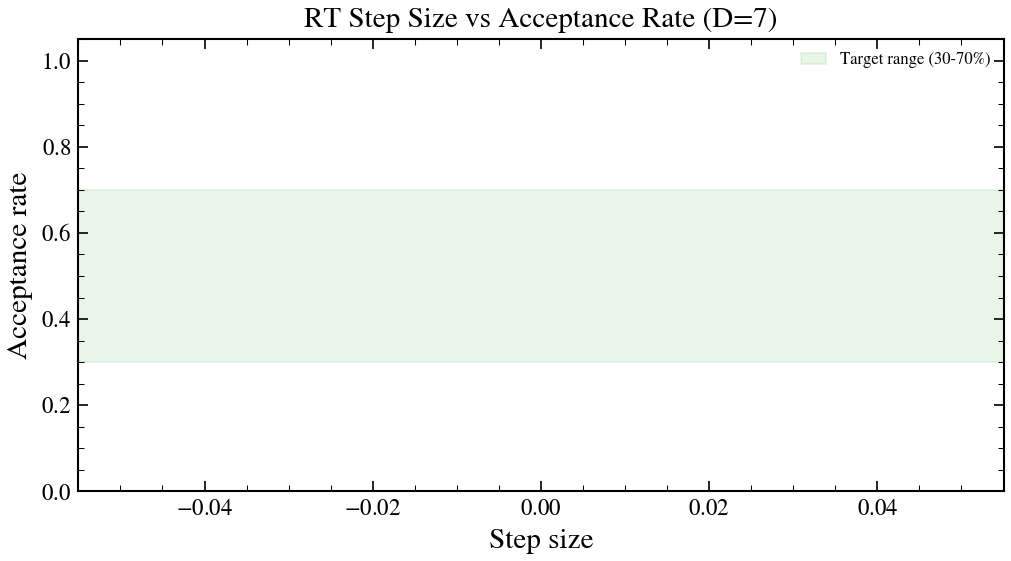

In [10]:
# --- FIGURE 4: Step size vs acceptance (empirical sweep) ---
# Run quick RT with different step sizes on the D=7 model
step_sizes = [0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3, 0.5]
acceptances = []

for ss in step_sizes:
    try:
        result_ss = fitter_param.run(
            "raytrace",
            init_from=result_map,
            n_steps=100,
            n_burnin=20,
            step_size=ss,
            n_leapfrog_steps=15,
        )
        acc = result_ss.diagnostics.get("acceptance_rate", np.nan)
        acceptances.append(float(acc) if acc is not None else np.nan)
    except Exception:
        acceptances.append(np.nan)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(step_sizes, acceptances, "o-", color=COLORS["rt"], lw=1.5, ms=6)
ax.axhspan(0.3, 0.7, alpha=0.1, color=COLORS["nuts"], label="Target range (30-70%)")
ax.set_xlabel("Step size")
ax.set_ylabel("Acceptance rate")
ax.set_title("RT Step Size vs Acceptance Rate (D=7)")
ax.legend(fontsize=8, frameon=False)
ax.set_ylim(0, 1.05)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "08_step_size_acceptance.png"), bbox_inches="tight")
plt.show()

## Summary

| Feature | RT | NUTS | geoVI |
|---------|-----|------|-------|
| Exact MCMC | Yes | Yes | No (approximate) |
| Scales to D>100 | Yes | No | Yes |
| Gradient noise resilience | Excellent | Poor | Good |
| Tuning parameters | step_size, n_leapfrog | max_tree_depth | n_samples, n_iterations |
| Key diagnostic | Acceptance rate | Divergences | KL convergence |

**When to use RT**: Any model where you want exact MCMC samples. Start
with MAP initialization, then run RT. Check acceptance rate (target 30-70%)
and ESS (target >100 per parameter).